In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import keras_tuner as kt
from keras import layers, Sequential, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.layers import LSTM, Dropout, Dense

In [2]:
curah_hujan = pd.read_csv(r"C:\Users\Giana\OneDrive\Dokumen\!!! Tugas Akhir\Data\Hasil Coding\Data Gabung Curah Hujan Bulanan.csv")

# Normalisasi Data

In [3]:
fitur = ["curah_hujan", "kelembapan_udara", "kecepatan_angin", "suhu"]

In [4]:
total_data = len(curah_hujan)
window_size = 13
total_window = total_data - window_size

In [5]:
train_size = int(0.6 * total_window)
valid_size = int(0.2 * total_window)
test_size = total_window - train_size - valid_size

In [6]:
batas_train_size = train_size + window_size

In [7]:
scaler = MinMaxScaler()

scaler.fit(curah_hujan.iloc[:batas_train_size][fitur])
curah_hujan_scaled = scaler.transform(curah_hujan[fitur])

In [8]:
# Buat class DataWindow untuk training data di model lstm

class DataWindow():
    def __init__(
        self, raw_data, window_size, target_columns=0):
        self.raw_data = raw_data
        self.window_size = window_size
        self.target_columns = target_columns
        self.input, self.label = self.make_window(raw_data, window_size, target_columns)
        
    def make_window(self, data, window_size, target_col=0):
      X, y = [], []
      for i in range(len(data) - window_size):
          X.append(data[i:i + window_size, :])
          y.append(data[i + window_size, target_col])
      return np.array(X), np.array(y)
    
    # Buat grafik        
    def plot(
      self, model=None, plot_col=0, max_subplot=3
    ):
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        max_n = min(max_subplot, len(inputs))
        for n in range (max_n):
            plt.subplot(max_n, 1, n + 1)
            plt.ylabel(f"Fitur index {plot_col}")
            
            # Plot input
            input_data = inputs[n, :, plot_col]
            time_steps = range(-self.window_size, 0)
            plt.plot(time_steps, input_data, label="Inputs", marker="o", zorder=-10)
            
            # Plot label
            plt.scatter(0, labels[n], s=64)
            
            # Plot prediksi model
            if model is not None:
                input_model = inputs[n : n + 1, :, :]
                prediksi = model.predict(input_model, verbose=0)
                plt.scatter(0, prediksi[0, 0], marker="x", s=64)
                
            if n == 0:
                plt.legend()
        
        plt.xlabel("Bulan ke-")
        plt.tight_layout()
        plt.show()
            
    @property
    def sample_batch(self):
        result = getattr(self, "_sample_batch", None)
        if result is None:
            batch_size = 32
            input = self.input[:batch_size]
            labels = self.label[:batch_size]
            result = (input, labels)
            self._sample_batch = result
        return result

#### Transformasi Data Time Series

In [9]:
curah_hujan_window = DataWindow(curah_hujan_scaled, window_size, target_columns=0)

X_all, y_all = curah_hujan_window.input, curah_hujan_window.label

X_train, y_train = X_all[:train_size], y_all[:train_size]
X_valid, y_valid = X_all[train_size : train_size + valid_size], y_all[train_size : train_size + valid_size]
X_test, y_test = X_all[train_size + valid_size:], y_all[train_size + valid_size:]

print(f"X_train = {X_train.shape}, y_train = {y_train.shape}")
print(f"X_valid = {X_valid.shape}, y_valid = {y_valid.shape}")
print(f"X_test = {X_test.shape}, y_test = {y_test.shape}")

X_train = (64, 13, 4), y_train = (64,)
X_valid = (21, 13, 4), y_valid = (21,)
X_test = (22, 13, 4), y_test = (22,)


#### Slicing data keperluan grafik

In [10]:
class WindowHelper(DataWindow):
    def __init__(self, X_data, y_data, window_size, target_columns=0):
        self.input = X_data
        self.label = y_data
        self.window_size = window_size
        self.target_columns = target_columns

In [11]:
train_window = WindowHelper(X_train, y_train, window_size)
valid_window = WindowHelper(X_valid, y_valid, window_size)
test_window = WindowHelper(X_test, y_test, window_size)

# Membangun Model LSTM

### Mendefinisikan model LSTM

#### Buat model lstm

In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=50,
    mode="min",
    restore_best_weights=True
)

tf.keras.utils.set_random_seed(42)

In [13]:
keras.backend.clear_session()

lstm_model = Sequential([
    Input(shape=(window_size, X_train.shape[-1])),
    LSTM(64, return_sequences=False, activation="tanh"),
    Dropout(0.1),
    Dense(16, activation="relu"),
    Dense(64, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="linear")
])

lstm_model.compile(
    loss=MeanSquaredError(),
    optimizer=Adam(learning_rate=0.003999684359589883),
    metrics=[RootMeanSquaredError()]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,849 (81.44 KB)

 Trainable params: 20,849 (81.44 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = lstm_model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=125,
    validation_data=(X_valid, y_valid),
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/125
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0459 - root_mean_squared_error: 0.2142 - val_loss: 0.0204 - val_root_mean_squared_error: 0.1427
Epoch 2/125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0260 - root_mean_squared_error: 0.1611 - val_loss: 0.0189 - val_root_mean_squared_error: 0.1375
Epoch 3/125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0241 - root_mean_squared_error: 0.1553 - val_loss: 0.0190 - val_root_mean_squared_error: 0.1380
Epoch 4/125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0218 - root_mean_squared_error: 0.1477 - val_loss: 0.0206 - val_root_mean_squared_error: 0.1436
Epoch 5/125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0236 - root_mean_squared_error: 0.1537 - val_loss: 0.0197 - val_root_mean_squared_error: 0.1402
Epoch 6/125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0220 - root_mean_squared_error: 0.1482 - val_loss: 0.0180 - val_root_mean_squared_error: 0.1342
Epoch 7/125
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0214 -

In [15]:
performa_valid = {}
performa = {}

performa_valid["LSTM"] = lstm_model.evaluate(X_valid, y_valid, verbose=1)
performa["LSTM"] = lstm_model.evaluate(X_test, y_test, verbose=1)

print(f"Hasil evaluasi validasi     : {performa_valid}")
print(f"Hasil evaluasi testing      : {performa}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0119 - root_mean_squared_error: 0.1090
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0119 - root_mean_squared_error: 0.1089
Hasil evaluasi validasi     : {'LSTM': [0.0118892602622509, 0.10903788357973099]}
Hasil evaluasi testing      : {'LSTM': [0.011859619989991188, 0.10890188068151474]}


### Grafik loss selama training

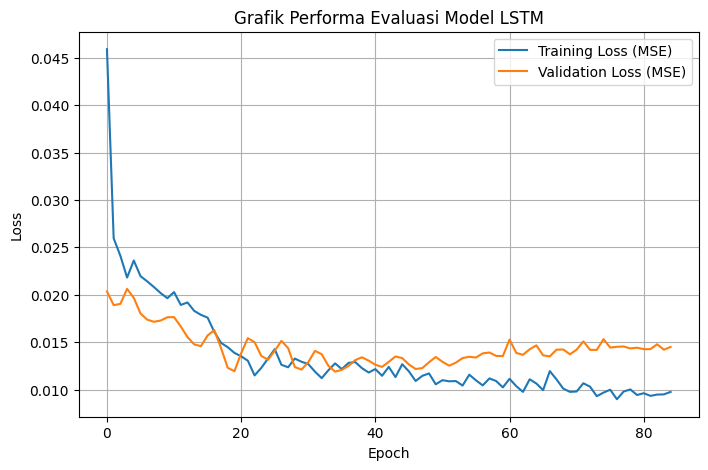

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss (MSE)")
plt.plot(history.history["val_loss"], label="Validation Loss (MSE)")
plt.title("Grafik Performa Evaluasi Model LSTM")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Grafik metrik selama training

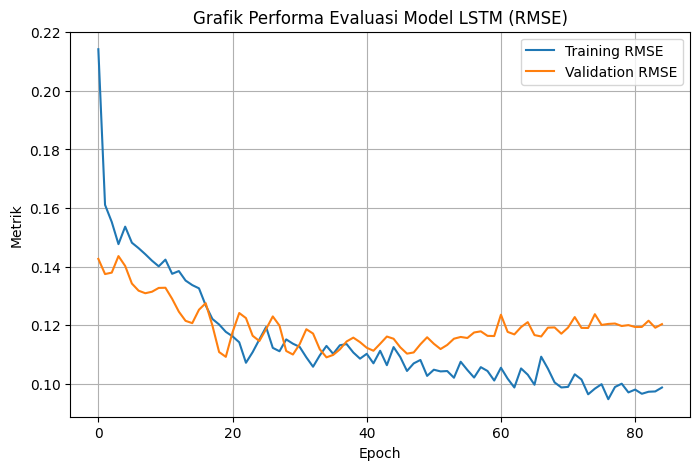

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["root_mean_squared_error"], label="Training RMSE")
plt.plot(history.history["val_root_mean_squared_error"], label="Validation RMSE")
plt.title("Grafik Performa Evaluasi Model LSTM (RMSE)")
plt.ylabel("Metrik")
plt.xlabel("Epoch")
plt.legend()
plt.grid(True)
plt.show()

### Hasil tebakan di data testing

Visualisasi Prediksi Model pada Data Testing:


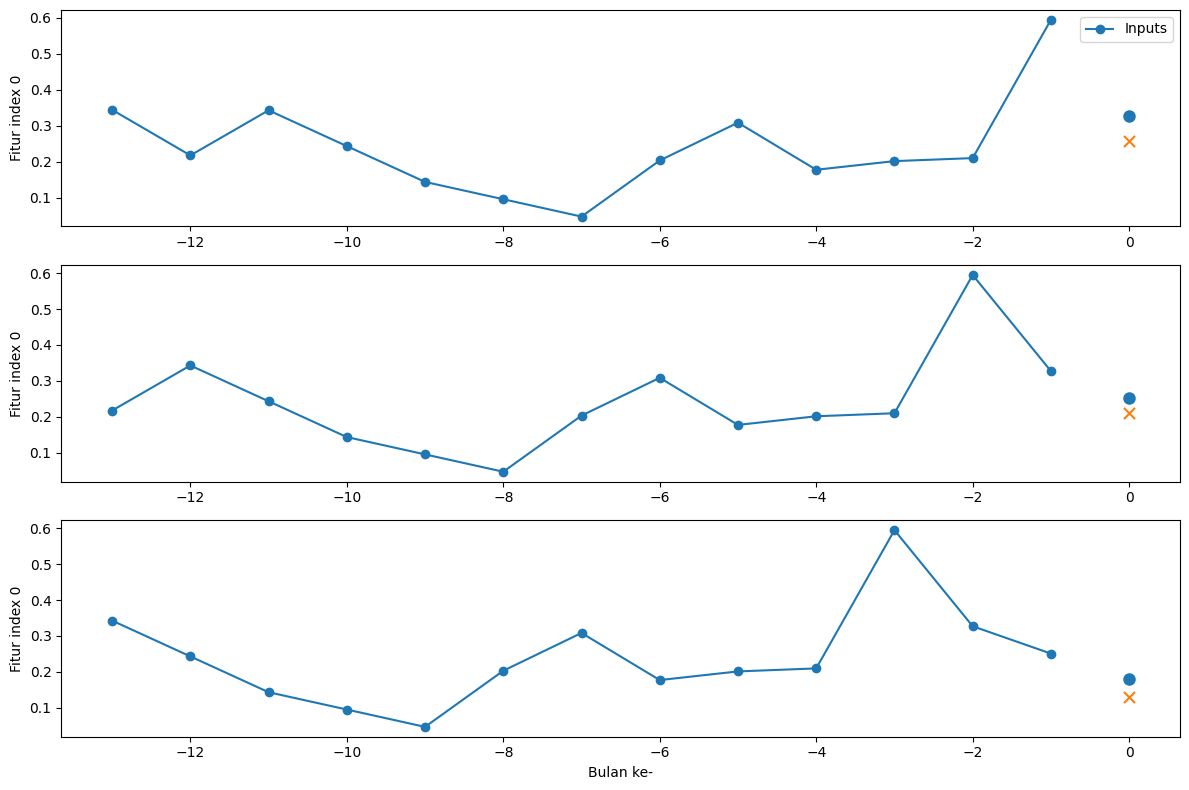

In [18]:
print("Visualisasi Prediksi Model pada Data Testing:")
test_window.plot(model=lstm_model, plot_col=0)

### Perbandingan hasil prediksi dan data asli

In [19]:
# Prediksi seluruh data testing
prediksi_hujan_scaled = lstm_model.predict(X_test)

# Menyiapkan dummy
dummy_prediksi = np.zeros((len(prediksi_hujan_scaled), X_train.shape[-1]))
dummy_aktual = np.zeros((len(y_test), X_train.shape[-1]))

# Memasukkan data prediksi dan aktual ke kolom curah hujan
dummy_prediksi[:, 0] = prediksi_hujan_scaled.flatten()
dummy_aktual[:, 0] = y_test.flatten()

# Melakukan inverse transform untuk kembali ke nilai satuan mm
prediksi_hujan = scaler.inverse_transform(dummy_prediksi)[:, 0]
aktual_hujan = scaler.inverse_transform(dummy_aktual)[:, 0]

# Menampilkan 5 hasil pertama
print("Perbandingan Curah Hujan (mm)")
for i in range(5):
    print(f"Hari ke-{i+1} | Aktual: {aktual_hujan[i]:.2f} mm | Prediksi: {prediksi_hujan[i]:.2f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Perbandingan Curah Hujan (mm)
Hari ke-1 | Aktual: 192.55 mm | Prediksi: 151.74 mm
Hari ke-2 | Aktual: 147.74 mm | Prediksi: 123.80 mm
Hari ke-3 | Aktual: 106.60 mm | Prediksi: 76.12 mm
Hari ke-4 | Aktual: 91.30 mm | Prediksi: 61.82 mm
Hari ke-5 | Aktual: 4.00 mm | Prediksi: 72.31 mm


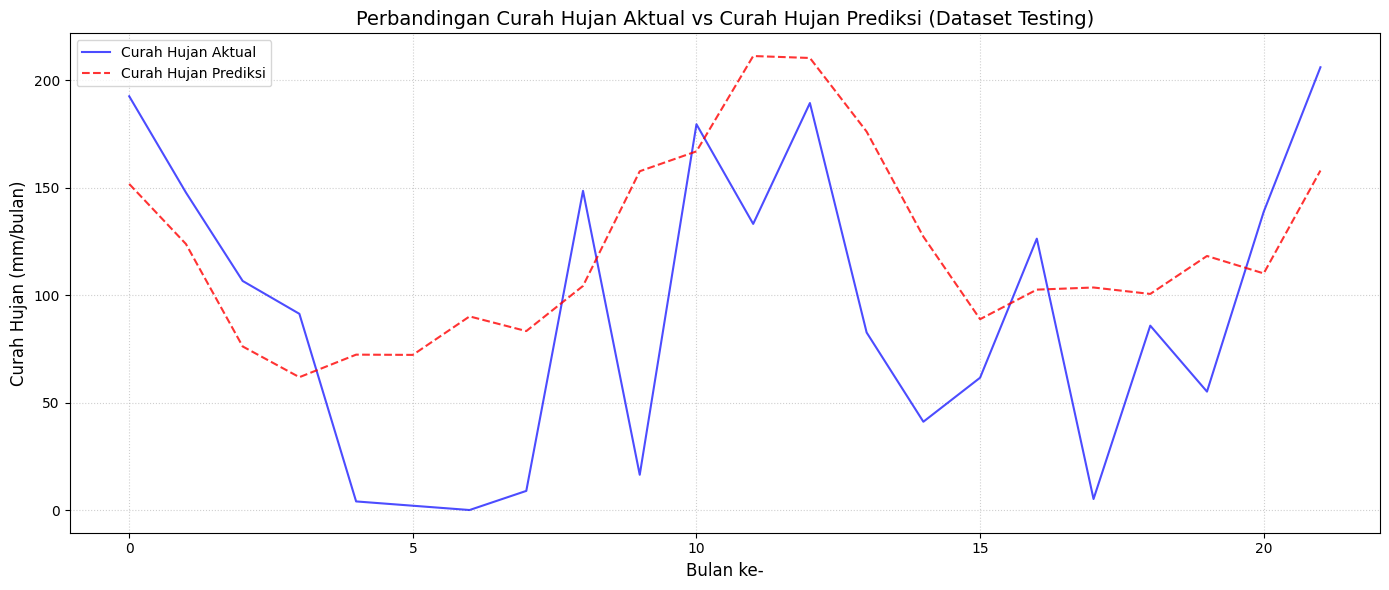

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(aktual_hujan, label="Curah Hujan Aktual", color="blue", alpha=0.7)
plt.plot(prediksi_hujan, label="Curah Hujan Prediksi", color="red", linestyle="--", alpha=0.8)
plt.title("Perbandingan Curah Hujan Aktual vs Curah Hujan Prediksi (Dataset Testing)", fontsize=14)
plt.xlabel("Bulan ke-", fontsize=12)
plt.ylabel("Curah Hujan (mm/bulan)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [21]:
# Cek akurasi

mse_testing = mean_squared_error(aktual_hujan, prediksi_hujan)
rmse_testing = np.sqrt(mse_testing)
mape_testing = mean_absolute_percentage_error(aktual_hujan, prediksi_hujan) * 100
r2_testing = r2_score(aktual_hujan, prediksi_hujan)

print(f"mse: {mse_testing}")
print(f"rmse: {rmse_testing}")
print(f"mape: {mape_testing}")
print(f"r2 score: {r2_testing}")

mse: 4108.207281582574
rmse: 64.0952984358648
mape: 1.844501620235898e+18
r2 score: 0.10800317115345515


#### Lihat data train

In [22]:
# Prediksi seluruh data testing
prediksi_hujan_scaled_train = lstm_model.predict(X_train)

# Menyiapkan dummy
dummy_prediksi_train = np.zeros((len(prediksi_hujan_scaled_train), X_train.shape[-1]))
dummy_aktual_train = np.zeros((len(y_train), X_train.shape[-1]))

# Memasukkan data prediksi dan aktual ke kolom curah hujan
dummy_prediksi_train[:, 0] = prediksi_hujan_scaled_train.flatten()
dummy_aktual_train[:, 0] = y_train.flatten()

# Melakukan inverse transform untuk kembali ke nilai satuan mm
prediksi_hujan_train = scaler.inverse_transform(dummy_prediksi_train)[:, 0]
aktual_hujan_train = scaler.inverse_transform(dummy_aktual_train)[:, 0]

# Menampilkan 5 hasil pertama
print("Perbandingan Curah Hujan (mm)")
for i in range(5):
    print(f"Hari ke-{i+1} | Aktual: {aktual_hujan_train[i]:.2f} mm | Prediksi: {prediksi_hujan_train[i]:.2f} mm")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Perbandingan Curah Hujan (mm)
Hari ke-1 | Aktual: 324.62 mm | Prediksi: 205.37 mm
Hari ke-2 | Aktual: 156.87 mm | Prediksi: 209.43 mm
Hari ke-3 | Aktual: 75.68 mm | Prediksi: 149.07 mm
Hari ke-4 | Aktual: 154.54 mm | Prediksi: 98.85 mm
Hari ke-5 | Aktual: 94.69 mm | Prediksi: 83.42 mm


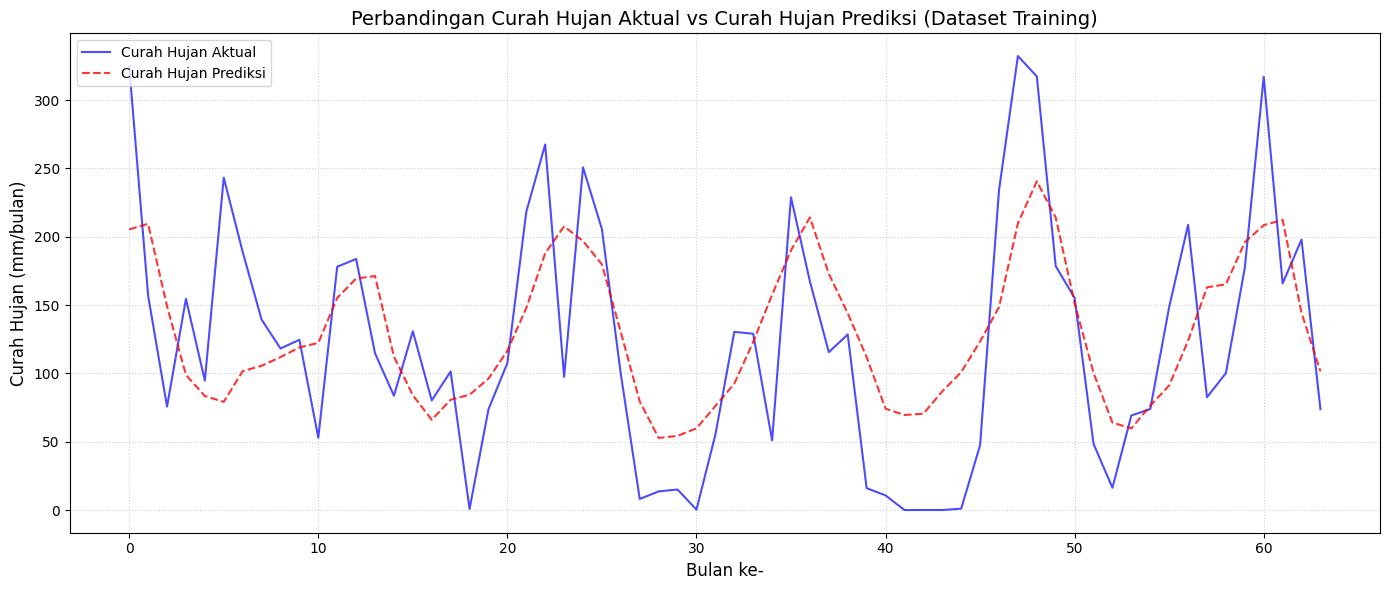

In [23]:
plt.figure(figsize=(14, 6))
plt.plot(aktual_hujan_train, label="Curah Hujan Aktual", color="blue", alpha=0.7)
plt.plot(prediksi_hujan_train, label="Curah Hujan Prediksi", color="red", linestyle="--", alpha=0.8)
plt.title("Perbandingan Curah Hujan Aktual vs Curah Hujan Prediksi (Dataset Training)", fontsize=14)
plt.xlabel("Bulan ke-", fontsize=12)
plt.ylabel("Curah Hujan (mm/bulan)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [24]:
# Cek akurasi

mse_training = mean_squared_error(aktual_hujan_train, prediksi_hujan_train)
rmse_training = np.sqrt(mse_training)
mape_training = mean_absolute_percentage_error(aktual_hujan_train, prediksi_hujan_train) * 100
r2_training = r2_score(aktual_hujan_train, prediksi_hujan_train)

print(f"mse: {mse_training}")
print(f"rmse: {rmse_training}")
print(f"mape: {mape_training}")
print(f"r2 score: {r2_training}")

mse: 4083.8068215845315
rmse: 63.90466979481649
mape: 1.5962283586178563e+18
r2 score: 0.475457772254707


#### Lihat data validasi

In [25]:
# Prediksi seluruh data valid
prediksi_hujan_scaled_valid = lstm_model.predict(X_valid)

# Menyiapkan dummy
dummy_prediksi_valid = np.zeros((len(prediksi_hujan_scaled_valid), X_valid.shape[-1]))
dummy_aktual_valid = np.zeros((len(y_valid), X_valid.shape[-1]))

# Memasukkan data prediksi dan aktual ke kolom curah hujan
dummy_prediksi_valid[:, 0] = prediksi_hujan_scaled_valid.flatten()
dummy_aktual_valid[:, 0] = y_valid.flatten()

# Melakukan inverse transform untuk kembali ke nilai satuan mm
prediksi_hujan_valid = scaler.inverse_transform(dummy_prediksi_valid)[:, 0]
aktual_hujan_valid = scaler.inverse_transform(dummy_aktual_valid)[:, 0]

# Menampilkan 5 hasil pertama
print("Perbandingan Curah Hujan (mm)")
for i in range(5):
    print(f"Hari ke-{i+1} | Aktual: {aktual_hujan_valid[i]:.2f} mm | Prediksi: {prediksi_hujan_valid[i]:.2f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Perbandingan Curah Hujan (mm)
Hari ke-1 | Aktual: 85.43 mm | Prediksi: 64.73 mm
Hari ke-2 | Aktual: 23.94 mm | Prediksi: 68.02 mm
Hari ke-3 | Aktual: 69.49 mm | Prediksi: 65.76 mm
Hari ke-4 | Aktual: 77.75 mm | Prediksi: 91.38 mm
Hari ke-5 | Aktual: 119.95 mm | Prediksi: 108.83 mm


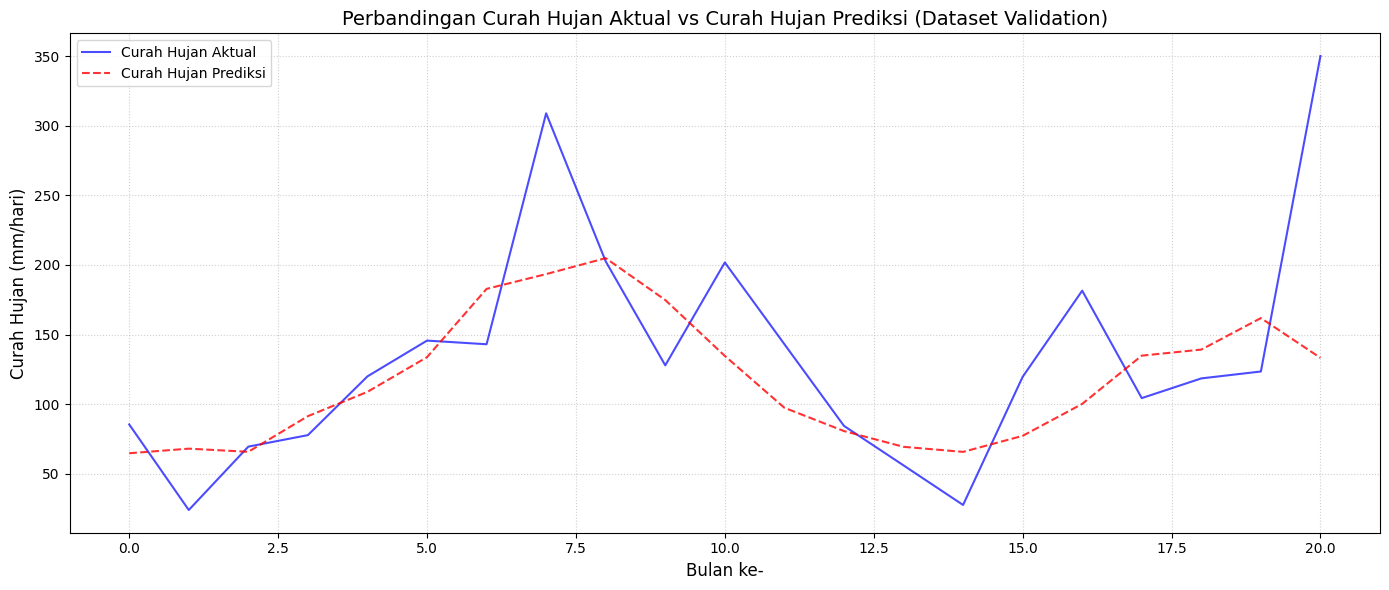

In [26]:
plt.figure(figsize=(14, 6))
plt.plot(aktual_hujan_valid, label="Curah Hujan Aktual", color="blue", alpha=0.7)
plt.plot(prediksi_hujan_valid, label="Curah Hujan Prediksi", color="red", linestyle="--", alpha=0.8)
plt.title("Perbandingan Curah Hujan Aktual vs Curah Hujan Prediksi (Dataset Validation)", fontsize=14)
plt.xlabel("Bulan ke-", fontsize=12)
plt.ylabel("Curah Hujan (mm/hari)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [27]:
# Cek akurasi

mse_valid = mean_squared_error(aktual_hujan_valid, prediksi_hujan_valid)
rmse_valid = np.sqrt(mse_valid)
mape_valid = mean_absolute_percentage_error(aktual_hujan_valid, prediksi_hujan_valid) * 100
r2_valid = r2_score(aktual_hujan_valid, prediksi_hujan_valid)

print(f"mse: {mse_valid}")
print(f"rmse: {rmse_valid}")
print(f"mape: {mape_valid}")
print(f"r2 score: {r2_valid}")

mse: 4118.474131929882
rmse: 64.17533897012062
mape: 38.266330650882004
r2 score: 0.347318183696086


# Hasil Prediksi

In [28]:
def forecast_hujan(model, data_scaled, n_bulan, window_size):
    input = data_scaled[-window_size:].copy()
    prediksi = []

    for i in range(n_bulan):
        input_reshape = input[-window_size:].reshape(1, window_size, data_scaled.shape[1])

        prediksi_scaled = model.predict(input_reshape, verbose=1)
        prediksi_nilai = prediksi_scaled[0, 0]
        prediksi.append(prediksi_nilai)

        fitur_lain = data_scaled[-1,1:].copy()
        baris_baru = np.hstack([[prediksi_nilai], fitur_lain])
        input = np.vstack([input, baris_baru])

    return np.array(prediksi)

In [29]:
n_bulan_prediksi = 6
forecast_scaled = forecast_hujan(lstm_model, curah_hujan_scaled, n_bulan_prediksi, window_size)

dummy_forecast = np.zeros((len(forecast_scaled), len(fitur)))
dummy_forecast[:, 0] = forecast_scaled
forecast_final = scaler.inverse_transform(dummy_forecast)[:, 0]

print(f"--- HASIL PREDIKSI CURAH HUJAN {n_bulan_prediksi} BULAN KE DEPAN ---")
for i, hujan in enumerate(forecast_final):
    print(f"Bulan ke-{i + 1} | {hujan:.2f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
--- HASIL PREDIKSI CURAH HUJAN 6 BULAN KE DEPAN ---
Bulan ke-1 | 209.72 mm
Bulan ke-2 | 212.10 mm
Bulan ke-3 | 186.30 mm
Bulan ke-4 | 153.84 mm
Bulan ke-5 | 125.07 mm
Bulan ke-6 | 106.71 mm


In [30]:
forecast = pd.DataFrame(forecast_final, columns=["Prediksi Curah Hujan"])
forecast.to_csv("prediksi_curah_hujan#1.csv", index=False)